In [5]:

%load_ext autoreload
%autoreload 2

In [6]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

from wrf_io import *
from scipy.io import savemat
from MITRotor import IEA10MW
from itertools import product
from scipy.interpolate import interp1d
from sklearn.preprocessing import StandardScaler

In [7]:
def annulus_average(theta, X):

    dtheta = np.gradient(theta)
    weights = dtheta / np.sum(dtheta)
    X_azim = np.sum(X * weights, axis=1)

    return X_azim

def rotor_average(r, X):
    # Takes annulus average quantities and performs rotor average

    dr = np.gradient(r)
    area_elements = 2 * np.pi * r * dr  # differential area for annular rings
    integrand = X * area_elements

    A = np.pi * (1 - r[0]**2)  # total area of annulus from R1 to R2

    X_rotor =  np.sum(integrand) / A

    return X_rotor

In [8]:
save_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep'

In [9]:
casenames = [
r's000_v000',
r's000_v025',
r's000_v050',
r's000_v100',
r's000_v200',
r's000_vn025',
r's000_vn050',
r's000_vn100',
r's000_vn200',
r's010_v000',
r's010_v025',
r's010_v050',
r's010_v100',
r's010_v200',
r's010_vn025',
r's010_vn050',
r's010_vn100',
r's010_vn200',
r's020_v000',
r's020_v025',
r's020_v050',
r's020_v100',
r's020_v200',
r's020_vn025',
r's020_vn050',
r's020_vn100',
r's020_vn200',
r's030_v000',
r's030_v025',
r's030_v050',
r's030_v100',
r's030_v200',
r's030_vn025',
r's030_vn050',
r's030_vn100',
r's030_vn200',
r'sn010_v000',
r'sn010_v025',
r'sn010_v050',
r'sn010_v100',
r'sn010_v200',
r'sn010_vn025',
r'sn010_vn050',
r'sn010_vn100',
r'sn010_vn200',
r'sn020_v000',
r'sn020_v025',
r'sn020_v050',
r'sn020_v100',
r'sn020_v200',
r'sn020_vn025',
r'sn020_vn050',
r'sn020_vn100',
r'sn020_vn200',
r'sn030_v000',
r'sn030_v025',
r'sn030_v050',
r'sn030_v100',
r'sn030_v200',
r'sn030_vn025',
r'sn030_vn050',
r'sn030_vn100',
r'sn030_vn200',
]

In [15]:
casenames = [
r's000_v000',
]

In [16]:
par_path = '/scratch/09909/smata/wrf_les_sweep/runs/10MW/rate/gad_sweep/parameters.pkl'

params = postproc.load_params(par_path)
data   = postproc.extract_sounding(params=params, local=False)
wrfles = postproc.load_data(params=params, casenames=casenames, local=False)

allocation     : ATM170028
partition      : spr
runtime        : 48:00:00
system         : stampede
num_nodes      : 2
exclude_time   : 10
save_interval  : 10
base_dir       : /scratch/09909/smata/wrf_les_sweep/runs/10MW/rate
wrf_path       : /work2/09909/smata/stampede3/WRF_LES
template_path  : /scratch/09909/smata/wrf_les_sweep/templates
turb_model     : iea10MW
rotor_model    : GAD
slice_loc      : 1
print_table    : True
plot_outer     : True
save_outer     : False
outer_align    : False
plot_inner     : True
save_inner     : False
save_both      : False
outer_pad      : 75
plot_profiles  : True
save_profiles  : True
batch_submit   : True
prof_type      : Idealized
shear_type     : Rate
shear          : [-0.03, -0.02, -0.01, 0, 0.01, 0.02, 0.03]
veer           : [-0.2, -0.1, -0.05, -0.025, 0, 0.025, 0.05, 0.1, 0.2]
excluded_pairs : []
Ufst           : 7


In [11]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [16]:
cases = [pair for pair in product(params['shear'], params['veer'])]
shears = [pair[0] for pair in cases]
veers = [pair[1] for pair in cases]

shears = np.array(shears)  
veers  = np.array(veers)

In [20]:
data['s000_v000'][:,2]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0.

In [17]:
xs = [0,1,1,1,2,3,3,3,3,3,4,5,5,5,6]
ys = [2,1,2,3,2,0,1,2,3,4,2,1,2,3,2]

leg_strs = ['$6.0$','$7.0$','$8.0$', '$9.0$', '$10.0$']

ind_rotor = np.zeros_like(casenames, dtype=float)
ct_rotor  = np.zeros_like(casenames, dtype=float)

nElements = wrfles[0]['Nelm']
nSections = wrfles[0]['Nsct']

ind_loc = np.zeros((nElements, nSections, len(casenames)))
ct_loc  = np.zeros((nElements, nSections, len(casenames)))

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * wrfles[0]['diameter']/2 + 378

wrf_pow      = np.zeros(len(casenames),dtype='longdouble')

# fig, ax = plt.subplots(figsize=(6, 5))

# casenames = ['s000_v000']
# casenames = ['U07']

rotor = IEA10MW()

for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    r = wrfles[count]['rOverR'] * rotor.R

    # Compute induction
    ind = 1 - np.mean(wrfles[count]['shapiroM'][-1] * wrfles[count]['u'],axis=0) / u_inf.T
    # ind = 1 - np.mean(wrfles[count]['u'],axis=0) / u_inf.T

    phi = np.deg2rad(np.mean(wrfles[count]['phi'], axis=0))
    Cl = np.mean(wrfles[count]['cl'], axis=0)
    Cd = np.mean(wrfles[count]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    sigma = [0.62582,0.51798,0.41014,0.30230,0.19446,0.12498,0.10792,0.09694,0.08596,0.07499,0.06401,0.05304,0.04206,0.03485,0.02985,0.02534,0.02203,0.01873,0.01625,0.01415,0.01205,0.00995,0.00785,0.00575,0.00365,0.00155]

    chord = [4.66770,4.94646,5.22522,5.50398,5.78274,5.95491,5.91736,5.61917,5.32097,5.02278,4.72458,4.42639,4.12819,3.81434,3.49131,3.18302,2.91082,2.63862,2.34715,2.04702,1.74690,1.44677,1.14664,0.84651,0.54639,0.24626]

    sigma = np.array(sigma)
    chord = np.array(chord)

    # sigma = sol_func(wrfles_bem[count]['rOverR'])

    sigma =  (np.ones_like(Cd.T) * sigma).T
    chord =  (np.ones_like(Cd.T) * chord).T

    # sigma = 3/nSections

    # Relative velocity
    # W = np.mean(wrfles_bem[count]['vrel'], axis=0) / (np.sqrt(u_inf**2 + v_inf**2)).T

    W = np.mean(wrfles[count]['vrel'], axis=0) * wrfles[count]['shapiroM'][-1] / (np.sqrt(u_inf**2 + v_inf**2)).T

    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma * W**2 * Cax
    # ct = sigma * W**2 * Cax

    rho = 1.225
    Nelm = 26

    W_dim = np.mean(wrfles[count]['vrel'], axis=0) * wrfles[count]['shapiroM'][-1]
    # W_dim = np.mean(wrfles[count]['vrel'], axis=0)


    L = 1/2 * rho * chord * (Cl * W_dim**2)
    D = 1/2 * rho * chord * (Cd * W_dim**2)

    FN = L * np.cos(phi) + D * np.sin(phi)
    FT = L * np.sin(phi) - D * np.cos(phi)

    dr = (rotor.R - rotor.hub_radius)/Nelm

    Nsct = 158

    T = np.sum(FN * dr * (3/Nsct))

    P = np.sum(FT * r * dr * (3/Nsct) * (np.mean(wrfles[count]['omega'], axis=0) * 2 * np.pi / 60))

    ind_loc[:,:,count] = ind
    ct_loc[:,:,count]  = ct

    # ct_annular  = 1/(2 * np.pi) * np.trapezoid(ct, np.linspace(0, 2*np.pi, nSections+1)[0:-1], axis=-1)
    # ind_annular = 1/(2 * np.pi) * np.trapezoid(ind, np.linspace(0, 2*np.pi, nSections+1)[0:-1], axis=-1)

    ct_annular = annulus_average(np.linspace(0, 2*np.pi, nSections), ct)
    ind_annular = annulus_average(np.linspace(0, 2*np.pi, nSections), ind)

    # ct_rotor[count]  = 2 * np.trapezoid(ct_annular * np.linspace(0,1,26), np.linspace(0,1,26))
    # ind_rotor[count] = 2 * np.trapezoid(ind_annular * np.linspace(0,1,26), np.linspace(0,1,26))

    # ct_rotor[count]  = 2 * np.trapezoid(ct_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
    # ind_rotor[count] = 2 * np.trapezoid(ind_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
# 
    ct_rotor[count]  = rotor_average(wrfles[count]['rOverR'], ct_annular)
    ind_rotor[count] = rotor_average(wrfles[count]['rOverR'], ind_annular)

    wrf_pow[count]          = P

    # ct_rotor[count] = rotor_average(np.linspace(0,1,26), ct_annular)
    # ind_rotor[count] = rotor_average(np.linspace(0,1,26), ind_annular)
    
    # ax.scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=110, edgecolor='none',color=colors[count],alpha=0.5,label = leg_strs[count], zorder = count + 2)

# a_mom = np.linspace(0,0.75,50)
# ct_mom = 4 * a_mom * (1 - a_mom)
# ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

# ct_mad = np.linspace(0,1.5,75)
# k1 = 0.2460
# k2 = 0.0586
# k3 = 0.0883
# a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
# ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=2)

# ax.set_xlabel('$a$ [-]', fontsize=fontsize)
# ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

# plt.legend(title='$U_{\infty}$ [m/s]')

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')


# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
# plt.show()

In [13]:
[ind_rotor[31], ct_rotor[31]]

[np.float64(0.2563566662478487), np.float64(0.7567187889192026)]

In [25]:
np.sum(FN * dr * sigma)

np.float64(1423314.9801845844)

In [34]:
wrf_pow[31]/1e3

np.longdouble('2880.5601429097345099')

In [19]:
wrf_pow/1e3

array([2810.09711695], dtype=float128)

In [43]:
dr

3.7346153846153842

In [28]:
np.mean(wrfles_bem[count]['omega'], axis=0) * 2 * np.pi / 60

array([0.62902629])

In [21]:
W_dim

array([[ 7.2799926,  7.3095155,  7.3082995, ...,  7.278062 ,  7.278843 ,
         7.2794867],
       [ 8.580216 ,  8.652432 ,  8.64604  , ...,  8.576304 ,  8.577983 ,
         8.57929  ],
       [10.183987 , 10.265939 , 10.254211 , ..., 10.181433 , 10.182773 ,
        10.183631 ],
       ...,
       [56.871696 , 56.87267  , 56.875088 , ..., 56.86649  , 56.867558 ,
        56.869766 ],
       [59.256897 , 59.25843  , 59.259895 , ..., 59.251217 , 59.252575 ,
        59.25442  ],
       [61.644302 , 61.64584  , 61.647274 , ..., 61.63838  , 61.64004  ,
        61.641956 ]], shape=(26, 158), dtype=float32)

In [44]:
FT

array([[ -35.98797784,  -37.01471558,  -36.92914252, ...,  -36.06997895,
         -36.04498388,  -36.01764365],
       [ -83.16182068,  -85.62144501,  -85.34489597, ...,  -83.21289192,
         -83.20622041,  -83.1893232 ],
       [-147.51739948, -150.8622454 , -150.37197812, ..., -147.51727354,
        -147.52748329, -147.52799328],
       ...,
       [ 178.55717545,  178.62915562,  178.56028465, ...,  178.40454618,
         178.3662602 ,  178.52990938],
       [ 124.11462846,  124.1587566 ,  124.23038806, ...,  124.12757807,
         124.09016638,  124.08773111],
       [  60.51948008,   60.54687166,   60.59040998, ...,   60.53567234,
          60.51494078,   60.50904292]], shape=(26, 158))

In [62]:
4 * 0.29904353 * (1 - 0.29904353)

0.8384659886605563

In [63]:
k3 *0.86684876**3 + k2 * 0.86684876**2 + k1 * 0.86684876

0.3147946720727234

In [21]:
np.zeros(len(casenames),dtype='longdouble')

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float128)

In [124]:
wrfles_bem[0]['rOverR']

array([0.04288751, 0.08042134, 0.11795516, 0.15548898, 0.19302281,
       0.23055663, 0.26809045, 0.30562428, 0.3431581 , 0.38069192,
       0.41822574, 0.45575957, 0.49329339, 0.53082721, 0.56836104,
       0.60589486, 0.64342868, 0.6809625 , 0.71849633, 0.75603015,
       0.79356397, 0.8310978 , 0.86863162, 0.90616544, 0.94369927,
       0.98123309])

In [32]:
rotor.chord_func(wrfles_bem[0]['rOverR'])

array([4.66772551, 4.94646327, 5.22520102, 5.50393878, 5.78267654,
       5.95488659, 5.91741297, 5.619217  , 5.32102104, 5.02282507,
       4.72462911, 4.42643314, 4.12823717, 3.81439031, 3.49135165,
       3.18304662, 2.91081356, 2.63858051, 2.347105  , 2.04698434,
       1.74686367, 1.446743  , 1.14662233, 0.84650167, 0.546381  ,
       0.24626033])

In [62]:
wrfles_bem[0]['rOverR']*0.97

array([0.04160089, 0.0780087 , 0.11441651, 0.15082431, 0.18723212,
       0.22363993, 0.26004774, 0.29645555, 0.33286336, 0.36927116,
       0.40567897, 0.44208678, 0.47849459, 0.5149024 , 0.5513102 ,
       0.58771801, 0.62412582, 0.66053363, 0.69694144, 0.73334925,
       0.76975705, 0.80616486, 0.84257267, 0.87898048, 0.91538829,
       0.9517961 ])

In [61]:
wrfles_bem[0]['rOverR']

array([0.04288751, 0.08042134, 0.11795516, 0.15548898, 0.19302281,
       0.23055663, 0.26809045, 0.30562428, 0.3431581 , 0.38069192,
       0.41822574, 0.45575957, 0.49329339, 0.53082721, 0.56836104,
       0.60589486, 0.64342868, 0.6809625 , 0.71849633, 0.75603015,
       0.79356397, 0.8310978 , 0.86863162, 0.90616544, 0.94369927,
       0.98123309])

In [47]:
np.round(r,3)

array([[ 4.267,  4.267,  4.267, ...,  4.267,  4.267,  4.267],
       [ 8.002,  8.002,  8.002, ...,  8.002,  8.002,  8.002],
       [11.737, 11.737, 11.737, ..., 11.737, 11.737, 11.737],
       ...,
       [90.163, 90.163, 90.163, ..., 90.163, 90.163, 90.163],
       [93.898, 93.898, 93.898, ..., 93.898, 93.898, 93.898],
       [97.633, 97.633, 97.633, ..., 97.633, 97.633, 97.633]],
      shape=(26, 158))

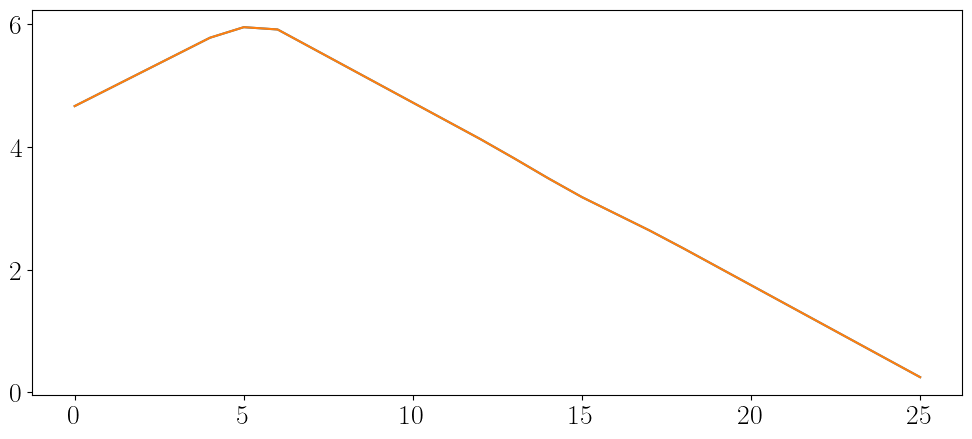

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))

chord = [
4.66770,
4.94646,
5.22522,
5.50398,
5.78274,
5.95491,
5.91736,
5.61917,
5.32097,
5.02278,
4.72458,
4.42639,
4.12819,
3.81434,
3.49131,
3.18302,
2.91082,
2.63862,
2.34715,
2.04702,
1.74690,
1.44677,
1.14664,
0.84651,
0.54639,
0.24626 
]

ax.plot(chord, label='case 1')
ax.plot(rotor.chord_func(wrfles_bem[count]['rOverR']), label='case 4')

In [26]:
sigma[:,0]

array([0.52226433, 0.29514794, 0.21257072, 0.16986018, 0.14376026,
       0.12394105, 0.10591682, 0.08822723, 0.07440718, 0.0633124 ,
       0.05420892, 0.04660497, 0.04015806, 0.03448137, 0.02947694,
       0.02520928, 0.02170867, 0.01859396, 0.01567598, 0.01299276,
       0.01056342, 0.00835345, 0.00633446, 0.00448273, 0.00277835,
       0.00120431])

Text(0.5, 1.0, 'Solidity')

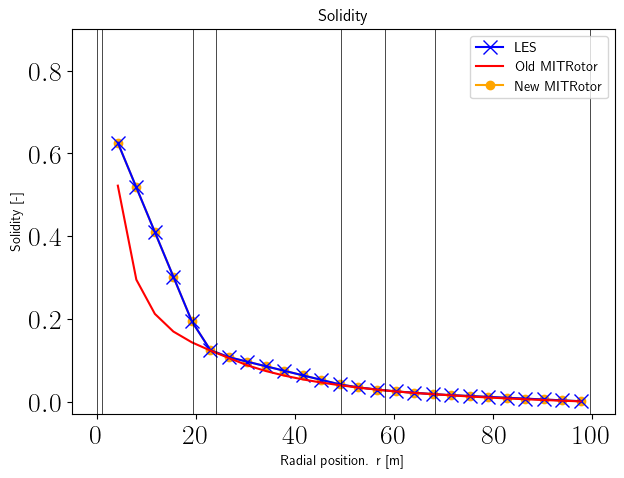

In [307]:
fig, ax = plt.subplots(figsize=(7, 5))

sigma = [
0.625818,
0.517977,
0.410137,
0.302296,
0.194455,
0.124975,
0.107916,
0.09694,
0.085964,
0.074988,
0.064012,
0.053036,
0.04206,
0.034849,
0.029849,
0.02534,
0.022033,
0.018726,
0.016251,
0.014151,
0.012051,
0.009951,
0.007851,
0.00575,
0.00365,
0.00155
    ]

ax.plot(r[:,0], sigma, color='b', markersize = 10, marker='x', label='LES',zorder=2)
ax.plot(r[:,0], rotor.solidity_func(wrfles_bem[count]['rOverR']), color = 'red', label='Old MITRotor')
ax.plot(r[:,0], sol_func(wrfles_bem[count]['rOverR']), color = 'orange', marker='o', label='New MITRotor',zorder=1)
ax.vlines(np.array([0.0, 0.01, 0.195, 0.242, 0.495, 0.585, 0.685, 1.0])*99.5,-1, 1, color='k', linewidth=0.5)
ax.legend()

ax.set_ylim([-0.03, 0.9])

ax.set_xlabel('Radial position. r [m]')
ax.set_ylabel('Solidity [-]')
ax.set_title('Solidity')

In [14]:
rotor.solidity_func(wrfles_bem[count]['rOverR'])

array([0.52226718, 0.29514933, 0.21257117, 0.16986045, 0.14376017,
       0.12394077, 0.10591777, 0.08822797, 0.0744079 , 0.06331297,
       0.05420948, 0.04660542, 0.04015852, 0.03448183, 0.02947729,
       0.02520949, 0.02170862, 0.01859368, 0.01567568, 0.01299253,
       0.0105632 , 0.00835329, 0.00633436, 0.00448269, 0.00277831,
       0.00120432])

In [25]:
3 * rotor.chord_func(wrfles_bem[count]['rOverR']) / (2 * np.pi * np.maximum(wrfles_bem[count]['rOverR'], 0.0001) * rotor.R),

(array([0.52226718, 0.29514933, 0.21257117, 0.16986045, 0.14376017,
        0.12394077, 0.10591777, 0.08822797, 0.0744079 , 0.06331297,
        0.05420948, 0.04660542, 0.04015852, 0.03448183, 0.02947729,
        0.02520949, 0.02170862, 0.01859368, 0.01567568, 0.01299253,
        0.0105632 , 0.00835329, 0.00633436, 0.00448269, 0.00277831,
        0.00120432]),)

In [26]:
rotor.chord_func(wrfles_bem[count]['rOverR'])

array([4.66772551, 4.94646327, 5.22520102, 5.50393878, 5.78267654,
       5.95488659, 5.91741297, 5.619217  , 5.32102104, 5.02282507,
       4.72462911, 4.42643314, 4.12823717, 3.81439031, 3.49135165,
       3.18304662, 2.91081356, 2.63858051, 2.347105  , 2.04698434,
       1.74686367, 1.446743  , 1.14662233, 0.84650167, 0.546381  ,
       0.24626033])

from scipy import interpolate

In [10]:
from scipy import interpolate
sol_func = interpolate.interp1d(np.array([0.02509648, 0.0338794 , 0.21441709, 0.26028342, 0.5071809 ,
       0.59501005, 0.69259799, 1.        ]), 3 * rotor.chord_func(np.array([0.02509648, 0.0338794 , 0.21441709, 0.26028342, 0.5071809 ,
       0.59501005, 0.69259799, 1.        ])) / (2 * np.pi * 99.5 * np.array([0.02509648, 0.0338794 , 0.21441709, 0.26028342, 0.5071809 ,
       0.59501005, 0.69259799, 1.        ])), kind='linear', fill_value="extrapolate")

In [12]:
sol_func(wrfles_bem[count]['rOverR'])

NameError: name 'count' is not defined

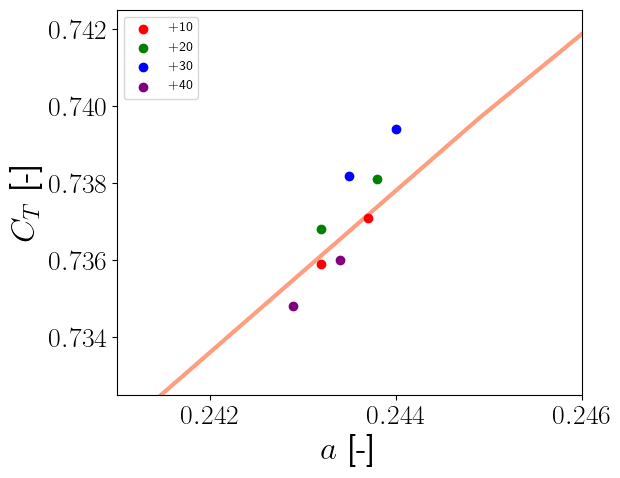

In [291]:
fig, ax = plt.subplots(figsize=(6, 5))

# up10_case0 = []
up10_case1 = [0.7975,0.2696]
up10_case2 = [0.7962,0.2690]
up10_case3 = [0.7371,0.2437]
up10_case4 = [0.7359,0.2432]

up20_case1 = [0.7979,0.2699]
up20_case2 = [0.7965,0.2692]
up20_case3 = [0.7381,0.2438]
up20_case4 = [0.7368,0.2432]

up30_case1 = [0.7958,0.2693]
up30_case2 = [0.7945,0.2687]
up30_case3 = [0.7394,0.2440]
up30_case4 = [0.7382,0.2435]

up40_case1 = [0.7963,0.2694]
up40_case2 = [0.7950,0.2688]
up40_case3 = [0.7360,0.2434]
up40_case4 = [0.7348,0.2429]

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=1)

ax.scatter(up10_case1[1],up10_case1[0], color='r', marker = 'o', label='+10%')
ax.scatter(up10_case2[1],up10_case2[0], color='r', marker = 'o')
ax.scatter(up10_case3[1],up10_case3[0], color='r', marker = 'o')
ax.scatter(up10_case4[1],up10_case4[0], color='r', marker = 'o')

ax.scatter(up20_case1[1],up20_case1[0], color='g', marker = 'o', label='+20%')
ax.scatter(up20_case2[1],up20_case2[0], color='g', marker = 'o')
ax.scatter(up20_case3[1],up20_case3[0], color='g', marker = 'o')
ax.scatter(up20_case4[1],up20_case4[0], color='g', marker = 'o')

ax.scatter(up30_case1[1],up30_case1[0], color='b', marker = 'o', label='+30%')
ax.scatter(up30_case2[1],up30_case2[0], color='b', marker = 'o')
ax.scatter(up30_case3[1],up30_case3[0], color='b', marker = 'o')
ax.scatter(up30_case4[1],up30_case4[0], color='b', marker = 'o')

ax.scatter(up40_case1[1],up40_case1[0], color='purple', marker = 'o', label='+40%')
ax.scatter(up40_case2[1],up40_case2[0], color='purple', marker = 'o')
ax.scatter(up40_case3[1],up40_case3[0], color='purple', marker = 'o')
ax.scatter(up40_case4[1],up40_case4[0], color='purple', marker = 'o')

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylim([0.7325,0.7425])
ax.set_xlim([0.241,0.246])

plt.legend(title='$U_{\infty}$ [m/s]')

ax.legend()

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')


# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()

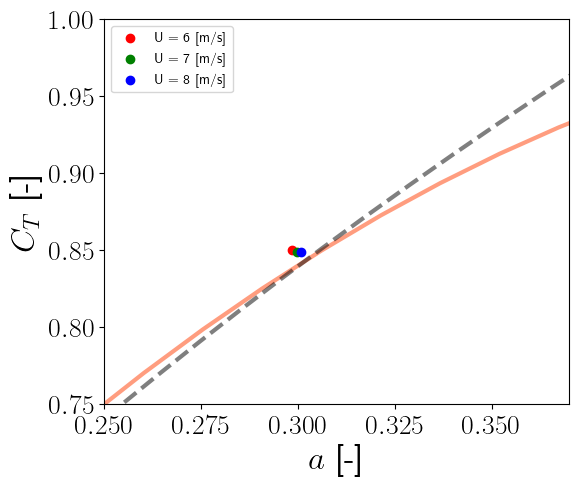

In [338]:
fig, ax = plt.subplots(figsize=(6, 5))

up10_case1 = [0.8498,0.2986]
up10_case2 = [0.8490,0.2998]
up10_case3 = [0.8484,0.3009]

a_mom = np.linspace(0,0.75,50)
ct_mom = 4 * a_mom * (1 - a_mom)
ax.plot(a_mom, ct_mom, '#ff3c00',linewidth=3,alpha = 0.5, zorder = 1)

ct_mad = np.linspace(0,1.5,75)
k1 = 0.2460
k2 = 0.0586
k3 = 0.0883
a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
ax.plot(a_mad, ct_mad, 'k--',linewidth=3,alpha=0.5,zorder=1)

ax.scatter(up10_case1[1],up10_case1[0], color='r', marker = 'o', label='U = 6 [m/s]')
ax.scatter(up10_case2[1],up10_case2[0], color='g', marker = 'o', label='U = 7 [m/s]')
ax.scatter(up10_case3[1],up10_case3[0], color='b', marker = 'o', label='U = 8 [m/s]')

ax.set_xlabel('$a$ [-]', fontsize=fontsize)
ax.set_ylabel('$C_T$ [-]', fontsize=fontsize)

ax.set_xlim([0,0.6])
ax.set_ylim([0,1.2])

ax.set_ylim([0.75,1])
ax.set_xlim([0.25,0.37])

plt.legend(title='$U_{\infty}$ [m/s]')

ax.legend()

# ax[0,0].axis('off')
# ax[0,1].axis('off')
# ax[0,3].axis('off')


# plt.savefig(f"./figs/wrf_10MW_rotor.png", bbox_inches="tight", dpi=600)
plt.show()